<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/notebooks/03_rq2_intensity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ2: Is more intensive chatbot use related to well-being?
**Owner: Person C**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(CLEAN_URL)
print(df.shape)

(1131, 17)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

## RQ2: Is more intensive chatbot use related to well-being?
**Step 1: Pearson correlation.** We measure how strongly use intensity and well-being move together. r ranges from −1 to +1; r² shows how much of the variation in well-being goes along with intensity.

In [3]:
r, p = stats.pearsonr(df["intensity"], df["well_being"])
print(f"Pearson r = {r:.2f}, p = {p:.2e}")
print(f"r squared = {r**2:.3f}")

Pearson r = 0.25, p = 4.90e-18
r squared = 0.064


**Step 2: Robustness check.** Spearman's rank correlation does not assume a straight-line relationship or normally distributed data.

In [4]:
rho, p_s = stats.spearmanr(df["intensity"], df["well_being"])
print(f"Spearman rho = {rho:.2f}, p = {p_s:.2e}")

Spearman rho = 0.28, p = 1.84e-21


**Step 3: Scatter plot.** Each dot is one participant; the red line shows the trend.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

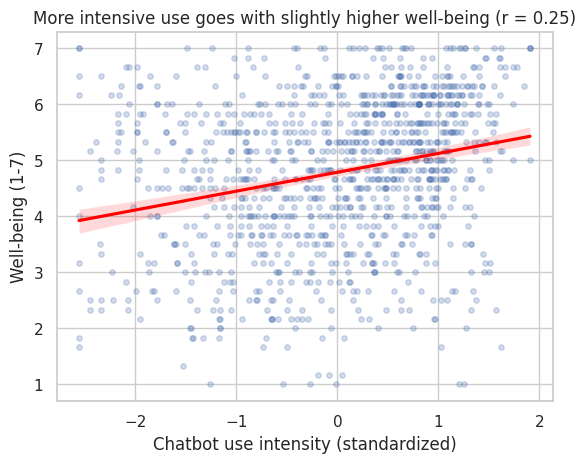

In [5]:
sns.regplot(data=df, x="intensity", y="well_being",
            scatter_kws={"alpha": 0.25, "s": 15}, line_kws={"color": "red"})
plt.xlabel("Chatbot use intensity (standardized)")
plt.ylabel("Well-being (1-7)")
plt.title(f"More intensive use goes with slightly higher well-being (r = {r:.2f})")
save_fig("rq2_scatter.png")
plt.show()

**Step 4: By group.** We check whether the relationship is the same for companion users and other users.

Companion (primary use): n = 134, r = 0.02, p = 0.7747
Other use: n = 997, r = 0.30, p = 0.0000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

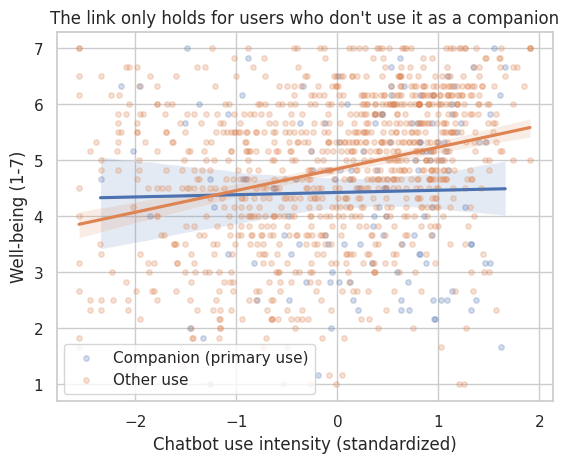

In [6]:
for name, group in df.groupby("companion_group"):
    rr, pp = stats.pearsonr(group["intensity"], group["well_being"])
    print(f"{name}: n = {len(group)}, r = {rr:.2f}, p = {pp:.4f}")
    sns.regplot(data=group, x="intensity", y="well_being", label=name,
                scatter_kws={"alpha": 0.25, "s": 15})

plt.xlabel("Chatbot use intensity (standardized)")
plt.ylabel("Well-being (1-7)")
plt.title("The link only holds for users who don't use it as a companion")
plt.legend()
save_fig("rq2_by_group.png")
plt.show()

**Interpretation.** Chatbot use intensity is positively but weakly related to well-being (r = 0.25, p < 0.001; Spearman ρ = 0.28); intensity accounts for about 6% of the variation in well-being. The relationship differs by group: it holds for participants who do not mainly use the chatbot as a companion (r = 0.30, n = 997), but not for companion users (r = 0.02, p = 0.77, n = 134). So more use is not uniformly good: for people who rely on the chatbot as a companion, using it more does not go along with feeling better. As this is a correlation from a one-time survey, it does not show cause and effect.